# House Price Prediction

## Problem Statement

The aim of this project is to build a Machine Learning model that can predict house prices based on different property features.

## Objective

To develop a regression model that can help estimate house prices and provide useful insights for real estate decision-making.

## Machine Learning Type

This is a Regression problem because the target variable is a continuous price value.

## Import Required Libraries

In this project, we use Python libraries for data handling, visualization, model training, and evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

import joblib

## Load California Housing Dataset

The California Housing dataset contains information about houses in California along with their median prices.

The dataset will be loaded directly from Scikit-learn.

In [2]:
housing = fetch_california_housing()


df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)


df["Price"] = housing.target


df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Dataset Overview

Checking the number of rows and columns helps us understand the size of our dataset.

In [3]:
df.shape

(20640, 9)

## Dataset Information

Checking data types and missing values before training the model.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Statistical Analysis

The describe function provides statistical information about numerical features.

In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Missing Value Check

Machine learning models work better when missing values are handled properly.

In [6]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

## Feature Correlation

Correlation helps identify relationships between features and house prices.

In [7]:
df.corr()["Price"].sort_values()

Latitude     -0.144160
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
HouseAge      0.105623
AveRooms      0.151948
MedInc        0.688075
Price         1.000000
Name: Price, dtype: float64

## Price Distribution

Visualizing the target variable helps understand the distribution of house prices.

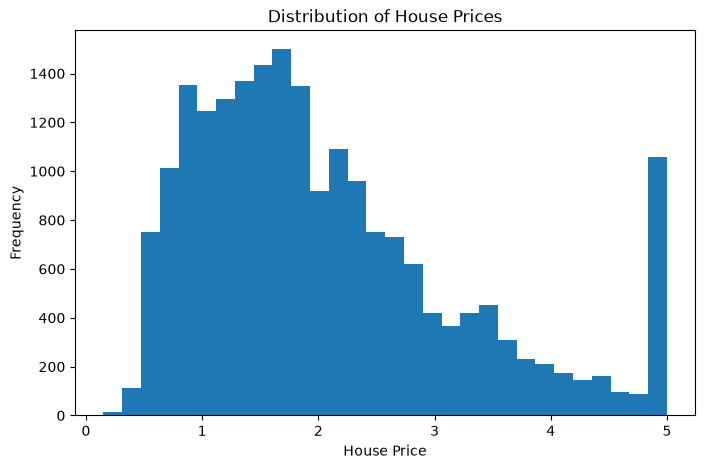

In [8]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Price"],
    bins=30
)

plt.xlabel("House Price")

plt.ylabel("Frequency")

plt.title(
    "Distribution of House Prices"
)

plt.show()

## Feature Relationship

Visualizing the relationship between median income and house prices.

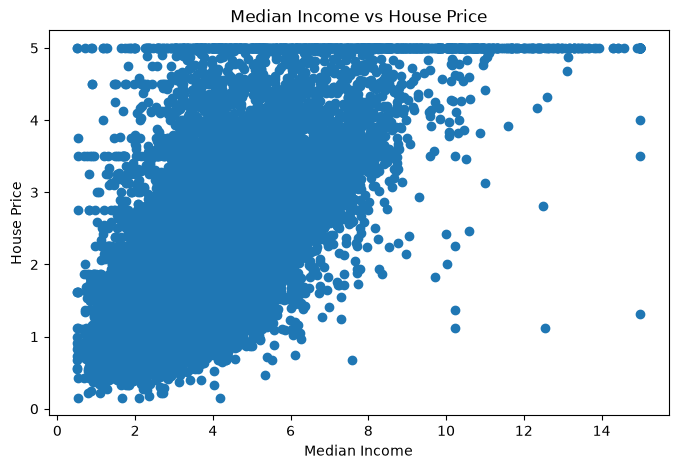

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["MedInc"],
    df["Price"]
)

plt.xlabel(
    "Median Income"
)

plt.ylabel(
    "House Price"
)

plt.title(
    "Median Income vs House Price"
)

plt.show()

## Feature Selection

The dataset is divided into independent variables (features) and dependent variable (target).

Features are the information used by the model to make predictions, while the target is the house price we want to predict.

In [10]:
X = df.drop(
    "Price",
    axis=1
)


y = df["Price"]


X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [11]:
X.shape

(20640, 8)

In [12]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64

## Splitting Dataset into Training and Testing Data

The dataset is divided into training and testing sets.

The training data is used to teach the model, while the testing data is used to evaluate how well the model performs on unseen data.

In [13]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

## Linear Regression Model

Linear Regression is a simple regression algorithm that learns the relationship between input features and the target price.

It is used as a baseline model to predict house prices.

In [15]:
from sklearn.linear_model import LinearRegression


lr_model = LinearRegression()


lr_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


## Linear Regression Evaluation

The model is evaluated using RMSE and R² score.

RMSE measures the average prediction error, while R² shows how well the model explains variations in house prices.

In [16]:
from sklearn.metrics import mean_squared_error, r2_score


lr_predictions = lr_model.predict(
    X_test
)


lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)


lr_r2 = r2_score(
    y_test,
    lr_predictions
)


print("Linear Regression RMSE:", lr_rmse)

print("Linear Regression R2 Score:", lr_r2)

Linear Regression RMSE: 0.7455813830127763
Linear Regression R2 Score: 0.575787706032451


## Random Forest Regression Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to make more accurate predictions.

It is usually more powerful than simple models because it can capture complex patterns in data.

In [17]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Random Forest Predictions

The trained Random Forest model is used to predict house prices on unseen test data.

In [18]:
rf_predictions = rf_model.predict(
    X_test
)

## Random Forest Evaluation

The Random Forest model is evaluated using RMSE and R² score.

In [19]:
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)


rf_r2 = r2_score(
    y_test,
    rf_predictions
)


print("Random Forest RMSE:", rf_rmse)

print("Random Forest R2 Score:", rf_r2)

Random Forest RMSE: 0.5059859946022769
Random Forest R2 Score: 0.8046244867176197


## Model Comparison

Both regression models are compared based on their evaluation metrics.

A lower RMSE and higher R² score indicate better performance.

In [20]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "RMSE":[
        lr_rmse,
        rf_rmse
    ],

    "R2 Score":[
        lr_r2,
        rf_r2
    ]

})


comparison

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Random Forest,0.505986,0.804624


## Selecting Best Performing Model

The model with the highest R² score is selected as the final model for deployment.

In [21]:
if rf_r2 > lr_r2:

    best_model = rf_model
    best_model_name = "Random Forest"

else:

    best_model = lr_model
    best_model_name = "Linear Regression"


print(
    "Best Model:",
    best_model_name
)

Best Model: Random Forest


## Feature Importance

Feature importance shows which features have the biggest impact on house price prediction.

This helps understand the model's decision-making process.

In [22]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


importance

,Feature,Importance
0,MedInc,0.524980
5,AveOccup,0.138367
6,Latitude,0.089035
7,Longitude,0.088474
1,HouseAge,0.054602
2,AveRooms,0.044216
4,Population,0.030662
3,AveBedrms,0.029663


## Visualizing Feature Importance

The graph shows the most important features used by the Random Forest model.

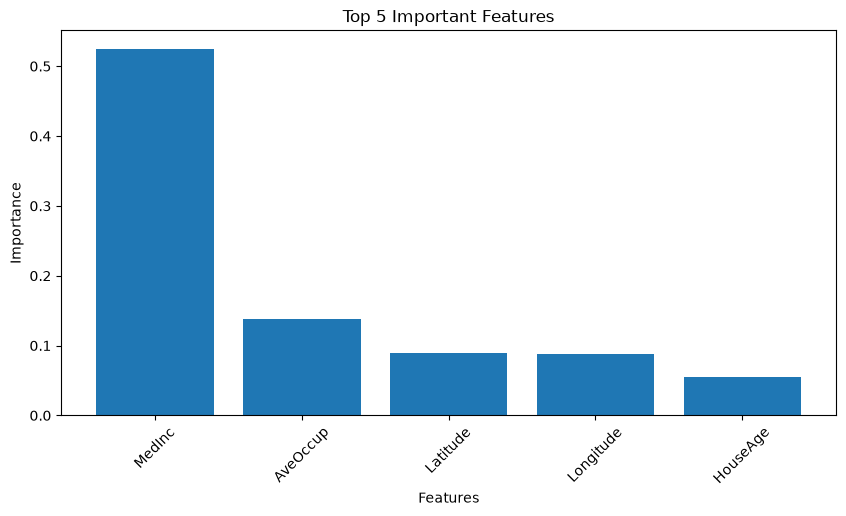

In [23]:
plt.figure(figsize=(10,5))


plt.bar(
    importance["Feature"][:5],
    importance["Importance"][:5]
)


plt.xticks(
    rotation=45
)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title(
    "Top 5 Important Features"
)

plt.show()

## Actual vs Predicted Prices

This visualization helps compare the actual house prices with the predicted prices from the model.

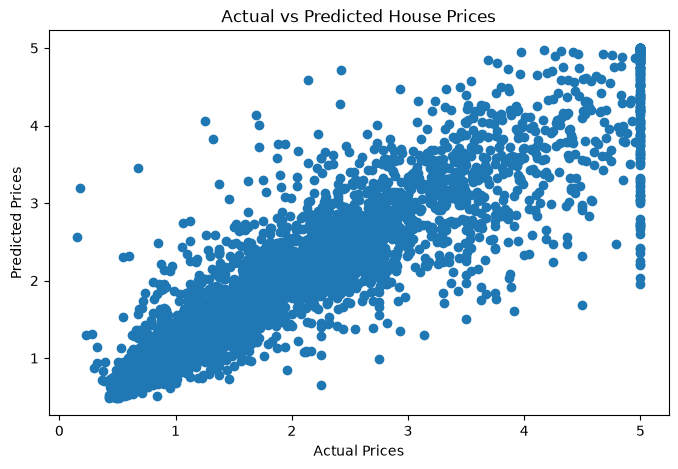

In [24]:
plt.figure(figsize=(8,5))


plt.scatter(
    y_test,
    rf_predictions
)


plt.xlabel(
    "Actual Prices"
)

plt.ylabel(
    "Predicted Prices"
)


plt.title(
    "Actual vs Predicted House Prices"
)


plt.show()

## Save Final Model

The best performing model is saved using joblib so it can be used later in the Streamlit application.

In [25]:
import joblib


joblib.dump(
    best_model,
    "house_price_model.pkl"
)


print(
    "Model saved successfully!"
)

Model saved successfully!


## Verify Model File

Checking whether the trained model file has been created successfully.

In [26]:
import os


os.path.exists(
    "house_price_model.pkl"
)

True

## Testing Saved Model

The saved model is loaded again to confirm that it works correctly for future predictions.

In [27]:
loaded_model = joblib.load(
    "house_price_model.pkl"
)


loaded_predictions = loaded_model.predict(
    X_test
)


loaded_predictions[:5]

array([0.50809  , 0.75064  , 4.9582073, 2.50172  , 2.24778  ])

## Streamlit Application

The trained machine learning model is deployed using Streamlit.

The application allows users to enter house features and get instant price predictions.